In [ ]:
from google.colab import userdata
import os

os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')


In [ ]:

!kaggle datasets download -d kavyasreeb/hair-type-dataset


Dataset URL: https://www.kaggle.com/datasets/kavyasreeb/hair-type-dataset
License(s): apache-2.0
 95% 166M/175M [00:01<00:00, 126MB/s]
100% 175M/175M [00:01<00:00, 128MB/s]


In [ ]:
!unzip "hair-type-dataset.zip"

Archive:  hair-type-dataset.zip
  inflating: data/Straight/000028d73-Nicole_Scherzinger.jpg  
  inflating: data/Straight/01-10-2019-latest-haircut-for-girls_Equal_Length_4PNG.jpg  
  inflating: data/Straight/01-10-2019-latest-haircut-for-girls_short_pixie_straight_undercut_3PNG.jpg  
  inflating: data/Straight/01b8ef4743e2a5d1b3e888ef18acdfd0.jpg  
  inflating: data/Straight/03e7316208c63582103294f3e1ef8b7b.jpg  
  inflating: data/Straight/051c0f399232bd22fb8ff55a6dde5441.jpg  
  inflating: data/Straight/060c671d89cba47235d3a8a620bed080.jpg  
  inflating: data/Straight/06faceb8ea130fb976a3339f52ba611d--hair-products-for-men-gentlemens-guide.jpg  
  inflating: data/Straight/0a1c060ba84f25dd6f353656818fb646.jpg  
  inflating: data/Straight/0a7bec97b58f02f16f1da241ed4d99dd.jpg  
  inflating: data/Straight/0f9d3172f6ec3206d6f76318830159b2.jpg  
  inflating: data/Straight/1-Saee-Hairstyle-Round-Face-Girls-With-Straightened-Hair.jpg  
  inflating: data/Straight/1-short-spiky-mens-haircut.jpg

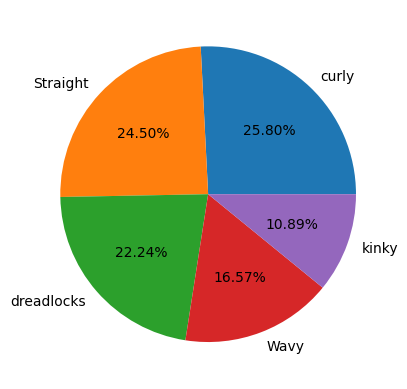

In [ ]:
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet50, ResNet50_Weights

from torchvision import transforms

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from copy import deepcopy

import os

from PIL import Image

def create_df(path):
    dd = {"images": [], "labels": []}
    for i in os.listdir(path):
        styles = os.path.join(path, i)
        for j in os.listdir(styles):
            dd["images"] += [os.path.join(styles, j)]
            dd["labels"] += [i]

    return pd.DataFrame(dd)


df = create_df("/content/data")

df["labels"].value_counts().plot(kind="pie", autopct="%0.2f%%")
plt.xlabel("")
plt.ylabel("")
plt.show()

label_index = {"Straight": 0,
              "Wavy": 1,
              "curly": 2,
              "dreadlocks": 3,
              "kinky": 4}

index_label = dict()

for i, j in label_index.items():
    index_label[j] = i

df["labels"] = df["labels"].map(label_index)

EPOCHS = 10
LR = 0.1
IMG_SIZE = 224
BATCH = 32

class Pipeline(Dataset):
    def __init__(self, data, transform):
        super(Pipeline, self).__init__()
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, x):
        img, label = self.data[x, 0], self.data[x, 1]
        img = Image.open(img).convert("RGB")
        img = np.array(img)
        img = self.transform(img)

        return img, label

transform = transforms.Compose([transforms.ToPILImage(),
                              transforms.ToTensor(),
                              transforms.Resize((IMG_SIZE, IMG_SIZE)),
                               transforms.RandomHorizontalFlip(p=0.3),
                               transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

train, validation = train_test_split(df.values, random_state=42, test_size=0.2)
val, test = train_test_split(validation, random_state=42, test_size=0.5)

train_ds = Pipeline(train, transform)
val_ds = Pipeline(val, transform)

train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=False)
val_dl = DataLoader(val_ds, batch_size=BATCH, shuffle=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

class HairStyle(nn.Module):
    def __init__(self, model):
        super(HairStyle, self).__init__()
        self.model = model

    def forward(self, x):
        return nn.functional.softmax(self.model(x), dim=1)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:01<00:00, 86.0MB/s]


Epoch 1 train loss 0.0445721203324485 acc 0.581293157564344 val loss 0.04280883343375508 acc 0.7286432160804021
Epoch 2 train loss 0.03439357508224133 acc 0.8487131198995606 val loss 0.036300368344963495 acc 0.9045226130653267
Epoch 3 train loss 0.03100510606657987 acc 0.9347143753923415 val loss 0.03559442800493096 acc 0.8994974874371859
Epoch 4 train loss 0.029925693188982794 acc 0.9623352165725048 val loss 0.035343443628531604 acc 0.8944723618090452
Epoch 5 train loss 0.029386509609761212 acc 0.9748901443816698 val loss 0.035377150803954156 acc 0.9095477386934674
Epoch 6 train loss 0.029130989511433593 acc 0.9817953546767106 val loss 0.03516631599646717 acc 0.9045226130653267
Epoch 7 train loss 0.02905619136956377 acc 0.9830508474576272 val loss 0.03546147879643656 acc 0.914572864321608
Epoch 8 train loss 0.02892497441937769 acc 0.9849340866290018 val loss 0.03496609560808345 acc 0.8994974874371859
Epoch 9 train loss 0.02887132110942929 acc 0.9855618330194601 val loss 0.035201775967

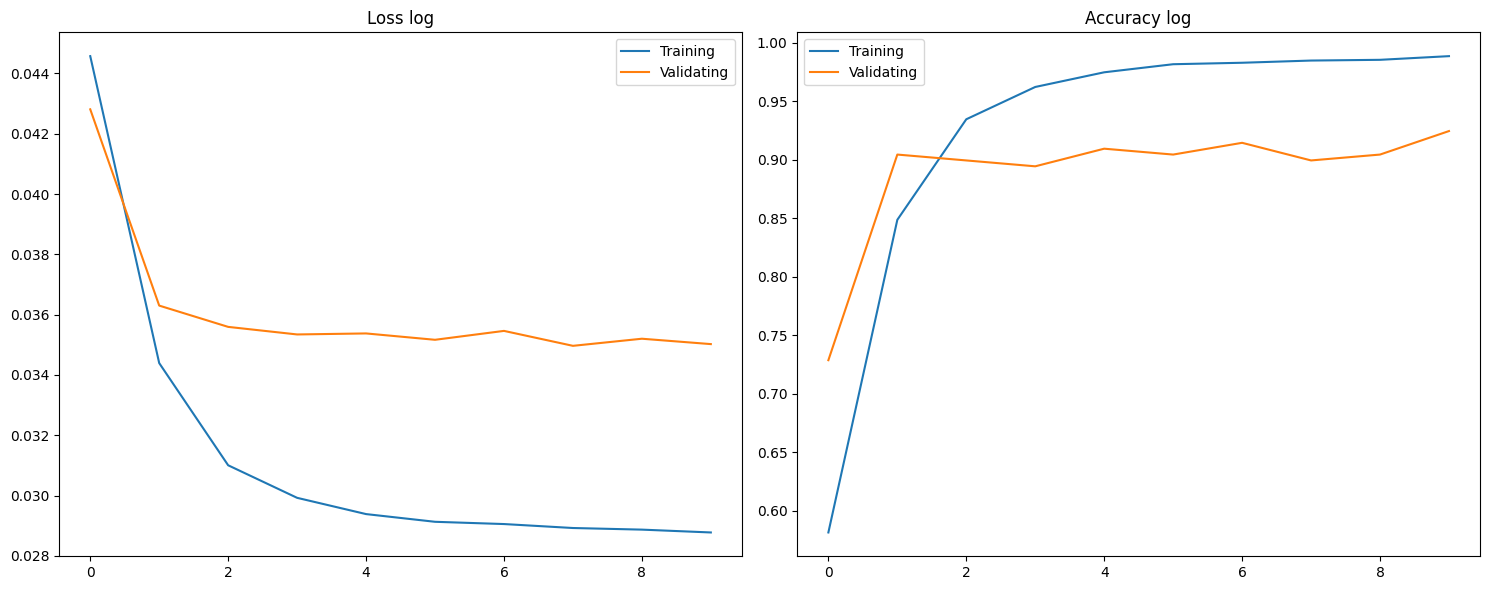

In [ ]:
resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
num_ftrs = resnet.fc.in_features
resnet.fc = nn.Linear(num_ftrs, 5)

model = HairStyle(resnet)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

best_model = deepcopy(model)
best_acc = 0

train_loss = []
train_acc = []
val_loss = []
val_acc = []

for i in range(1, EPOCHS+1):
    model.train()

    diff = 0
    acc = 0
    total = 0

    for data, target in train_dl:
        optimizer.zero_grad()
        if torch.cuda.is_available():
            data, target = data.cuda(), target.cuda()

        out = model(data)
        loss = criterion(out, target)
        diff += loss.item()
        acc += (out.argmax(1) == target).sum().item()
        total += out.size(0)
        loss.backward()
        optimizer.step()

    train_loss += [diff/total]
    train_acc += [acc/total]

    diff = 0
    acc = 0
    total = 0

    model.eval()

    with torch.no_grad():
        for data, target in val_dl:
            if torch.cuda.is_available():
                data, target = data.cuda(), target.cuda()

            out = model(data)
            loss = criterion(out, target)
            diff += loss.item()
            acc += (out.argmax(1) == target).sum().item()
            total += out.size(0)

    val_loss += [diff/total]
    val_acc += [acc/total]

    if val_acc[-1] >= best_acc:
        best_acc = val_acc[-1]
        best_model = deepcopy(model)

    print("Epoch {} train loss {} acc {} val loss {} acc {}".format(i, train_loss[-1], train_acc[-1],
                                                                   val_loss[-1], val_acc[-1]))


fig, axes = plt.subplots(ncols=2, figsize=(15, 6))

index = 0
axes[index].plot(train_loss, label="Training")
axes[index].plot(val_loss, label="Validating")
axes[index].legend()
axes[index].set_title("Loss log")
axes[index].set_xlabel("")
axes[index].set_ylabel("")

index += 1

axes[index].plot(train_acc, label="Training")
axes[index].plot(val_acc, label="Validating")
axes[index].legend()
axes[index].set_title("Accuracy log")
axes[index].set_xlabel("")
axes[index].set_ylabel("")

plt.tight_layout()
plt.show()

def predict(img):
    img = Image.open(img).convert("RGB")
    img = np.array(img)
    img = transform(img)
    img = img.view(1, 3, 224, 224)
    best_model.eval()
    with torch.no_grad():
        if torch.cuda.is_available():
            img = img.cuda()

    out = best_model(img)

    index = out.argmax(1).item()

    return index, out[0][index].item()


truth = []
preds = []
probas = []

for i in range(test.shape[0]):
    truth += [test[i, 1]]
    pred, proba = predict(test[i, 0])
    preds += [pred]
    probas += [round(proba*100, 2)]

              precision    recall  f1-score   support

           0       0.97      0.89      0.93        65
           1       0.74      0.81      0.77        21
           2       0.91      0.96      0.93        52
           3       0.95      0.97      0.96        40
           4       0.86      0.82      0.84        22

    accuracy                           0.91       200
   macro avg       0.88      0.89      0.89       200
weighted avg       0.91      0.91      0.91       200



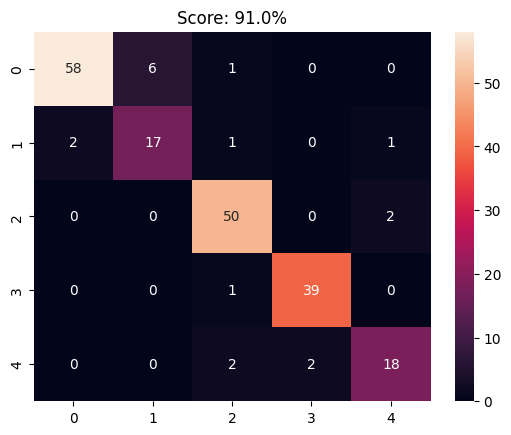

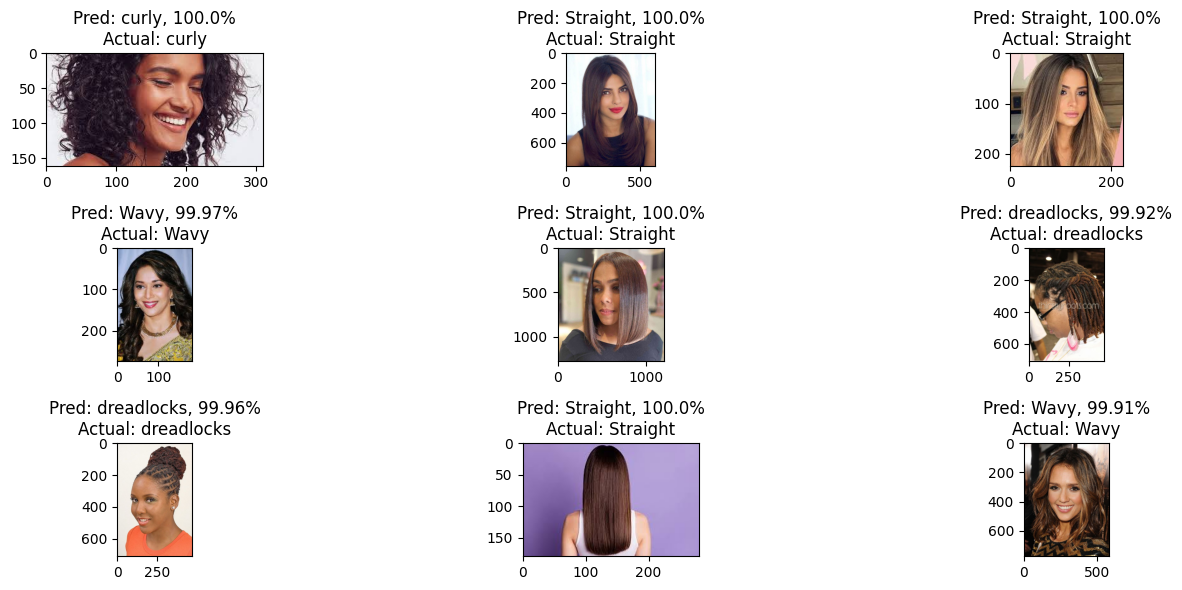

In [ ]:
print(classification_report(preds, truth))
sns.heatmap(confusion_matrix(preds, truth), annot=True, fmt='d')
plt.title("Score: {}%".format(round(accuracy_score(preds, truth)*100, 2)))
plt.show()

index = 0

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 6))
for i in range(3):
    for j in range(3):
        axes[i][j].imshow(np.array(Image.open(test[index, 0]).convert("RGB")))
        axes[i][j].set_title("Pred: {}, {}%\nActual: {}".format(index_label[preds[index]],
                                                               probas[index],
                                                               index_label[truth[index]]))
        index += 1
plt.tight_layout()
plt.show()

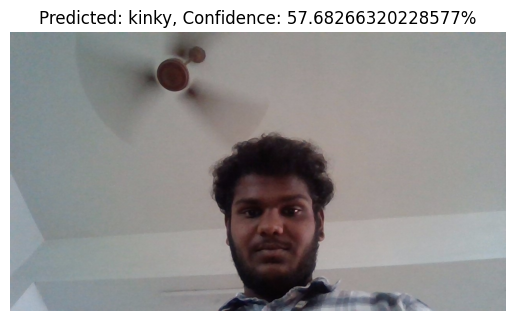

In [ ]:

def classify_hair_image(img_path):
    img = Image.open(img_path).convert("RGB")
    pred, proba = predict(img_path)
    predicted_label = index_label[pred]


    plt.imshow(np.array(img))
    plt.title(f"Predicted: {predicted_label}, Confidence: {proba*100}%")
    plt.axis('off')
    plt.show()


input_image_path = "/content/WIN_20241106_11_54_11_Pro.jpg"
classify_hair_image(input_image_path)
